# Intuition behind CRPS

In many forecasting applications, probabilistic methods have become a standard tool. The reason is that predicting the point forecast is not enough for decision-making. The predicted uncertainty provides valuable information that can be used to make better decisions, such as risk management or inventory control. How to evaluate the performance of probabilistic forecasts? A naive approach is to collapse the output of the probabilistic model into a single point forecast (say, using the mean) and then use the standard metrics for point forecasts. A better alternative is to use the **Continuous Ranked Probability Score (CRPS)**. This metric is a generalization of the mean absolute error (MAE) to the probabilistic setting. It is computed as the integral of the squared difference between the cumulative distribution function (CDF) of the predicted distribution $F$ and the empirical CDF of the observation $y$:

$$\text{CRPS}(F, y) = \int_{-\infty}^{+\infty} \left( F(x) - \mathbb{1}(x \geq y) \right)^2 \, dx$$

Intuitively, the CRPS measures the "distance" between the predicted distribution and the observed value by comparing their CDFs at every point on the real line. The step function $\mathbb{1}(x \geq y)$ acts as the CDF of a point mass at $y$. When the predicted distribution is concentrated around the true value with appropriate spread, this integral is small; when the distribution is biased or overconfident/underconfident, the area between the two CDFs grows. In the special case where $F$ itself is a point mass at some predicted value $\hat{y}$, the CRPS reduces to $|y - \hat{y}|$, recovering the absolute error. This makes the CRPS directly comparable in scale to the MAE.

This property highlights a key advantage of the CRPS over a naive "collapse-then-evaluate" strategy: the CRPS simultaneously rewards **calibration** (the predicted uncertainty matches the true data-generating spread) and **sharpness** (the predicted distribution is as tight as possible while remaining calibrated). In contrast, collapsing to the mean and computing the MAE completely discards information about the predicted spread: a narrow and a wide distribution centered at the same point receive the same MAE, but different CRPS values.

In this notebook, we illustrate this difference by generating synthetic predictions where the error is drawn from normal distributions with varying location ($\mu$) and scale ($\sigma$) parameters, and then comparing the CRPS and MAE on a grid. Through this example, we get a better intuition of the relationship between the CRPS and MAE and how the CRPS encodes the size of the error.


## Prepare Notebook

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from pymc_marketing.metrics import crps
from sklearn.metrics import mean_absolute_error as mae

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/website_projects/.pixi/envs/default/lib/python3.13/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,
/Users/juanitorduz/Documents/website_projects/.pixi/envs/default/lib/python3.13/site-packages/pymc_marketing/pytensor_utils.py:34: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors


## Generate Synthetic Forecast

We sample $n = 50$ ground-truth observations $y_{\text{true}}$ from a standard normal distribution. We then generate synthetic forecasts as follow:

$$
y_{\text{pred}} =  y_{\text{true}} + \mu + \sigma \varepsilon, \quad \varepsilon \sim \text{Normal}(0, 1)
$$

The values of $\mu$ and $\sigma$ are sampled from a grid of $k = 21$ location shifts $\mu \in [-10, 10]$ and scale values $\sigma \in [0.1, 10]$. For each $(\mu, \sigma)$ pair we generate $1\,000$ posterior-like draws per observation, yielding a 5-dimensional `xarray.DataArray` with dimensions `(chain, draw, n, sigma, mu)`.

In [2]:
# random seed
seed: int = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)
# number of observations
n = 50
# true values
y_true = rng.normal(0, 1, size=n)
# number of draws
draws = 1_000
# number of grid points
k = 21
# location shifts
mus = np.linspace(-10, 10, k)
sigmas = np.linspace(0.1, 10, k)
# noise
noise = rng.normal(0, 1, size=(1, draws, n))
# scale
sigma = sigmas[np.newaxis, np.newaxis, :] * noise[..., np.newaxis]
# predictions
y_pred_array = (
    y_true[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    + mus[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :]
    + sigma[..., np.newaxis]
)
# predictions as xarray.DataArray
y_pred = xr.DataArray(
    y_pred_array,
    coords=([0], np.arange(draws), np.arange(n), sigmas, mus),
    dims=["chain", "draw", "n", "sigma", "mu"],
)

## Visualize Forecast

We plot predicted-vs-observed values with HDI (Highest Density Interval) bands for the four corner combinations of the $(\mu, \sigma)$ grid.This illustrates the extreme cases: small bias with tight spread, small bias with wide spread, large bias with tight spread, and large bias with wide spread. The dashed diagonal line marks perfect calibration ($y_{\text{pred}} = y_{\text{true}}$). We also compute the CRPS and MAE for each $(\mu, \sigma)$ pair. 

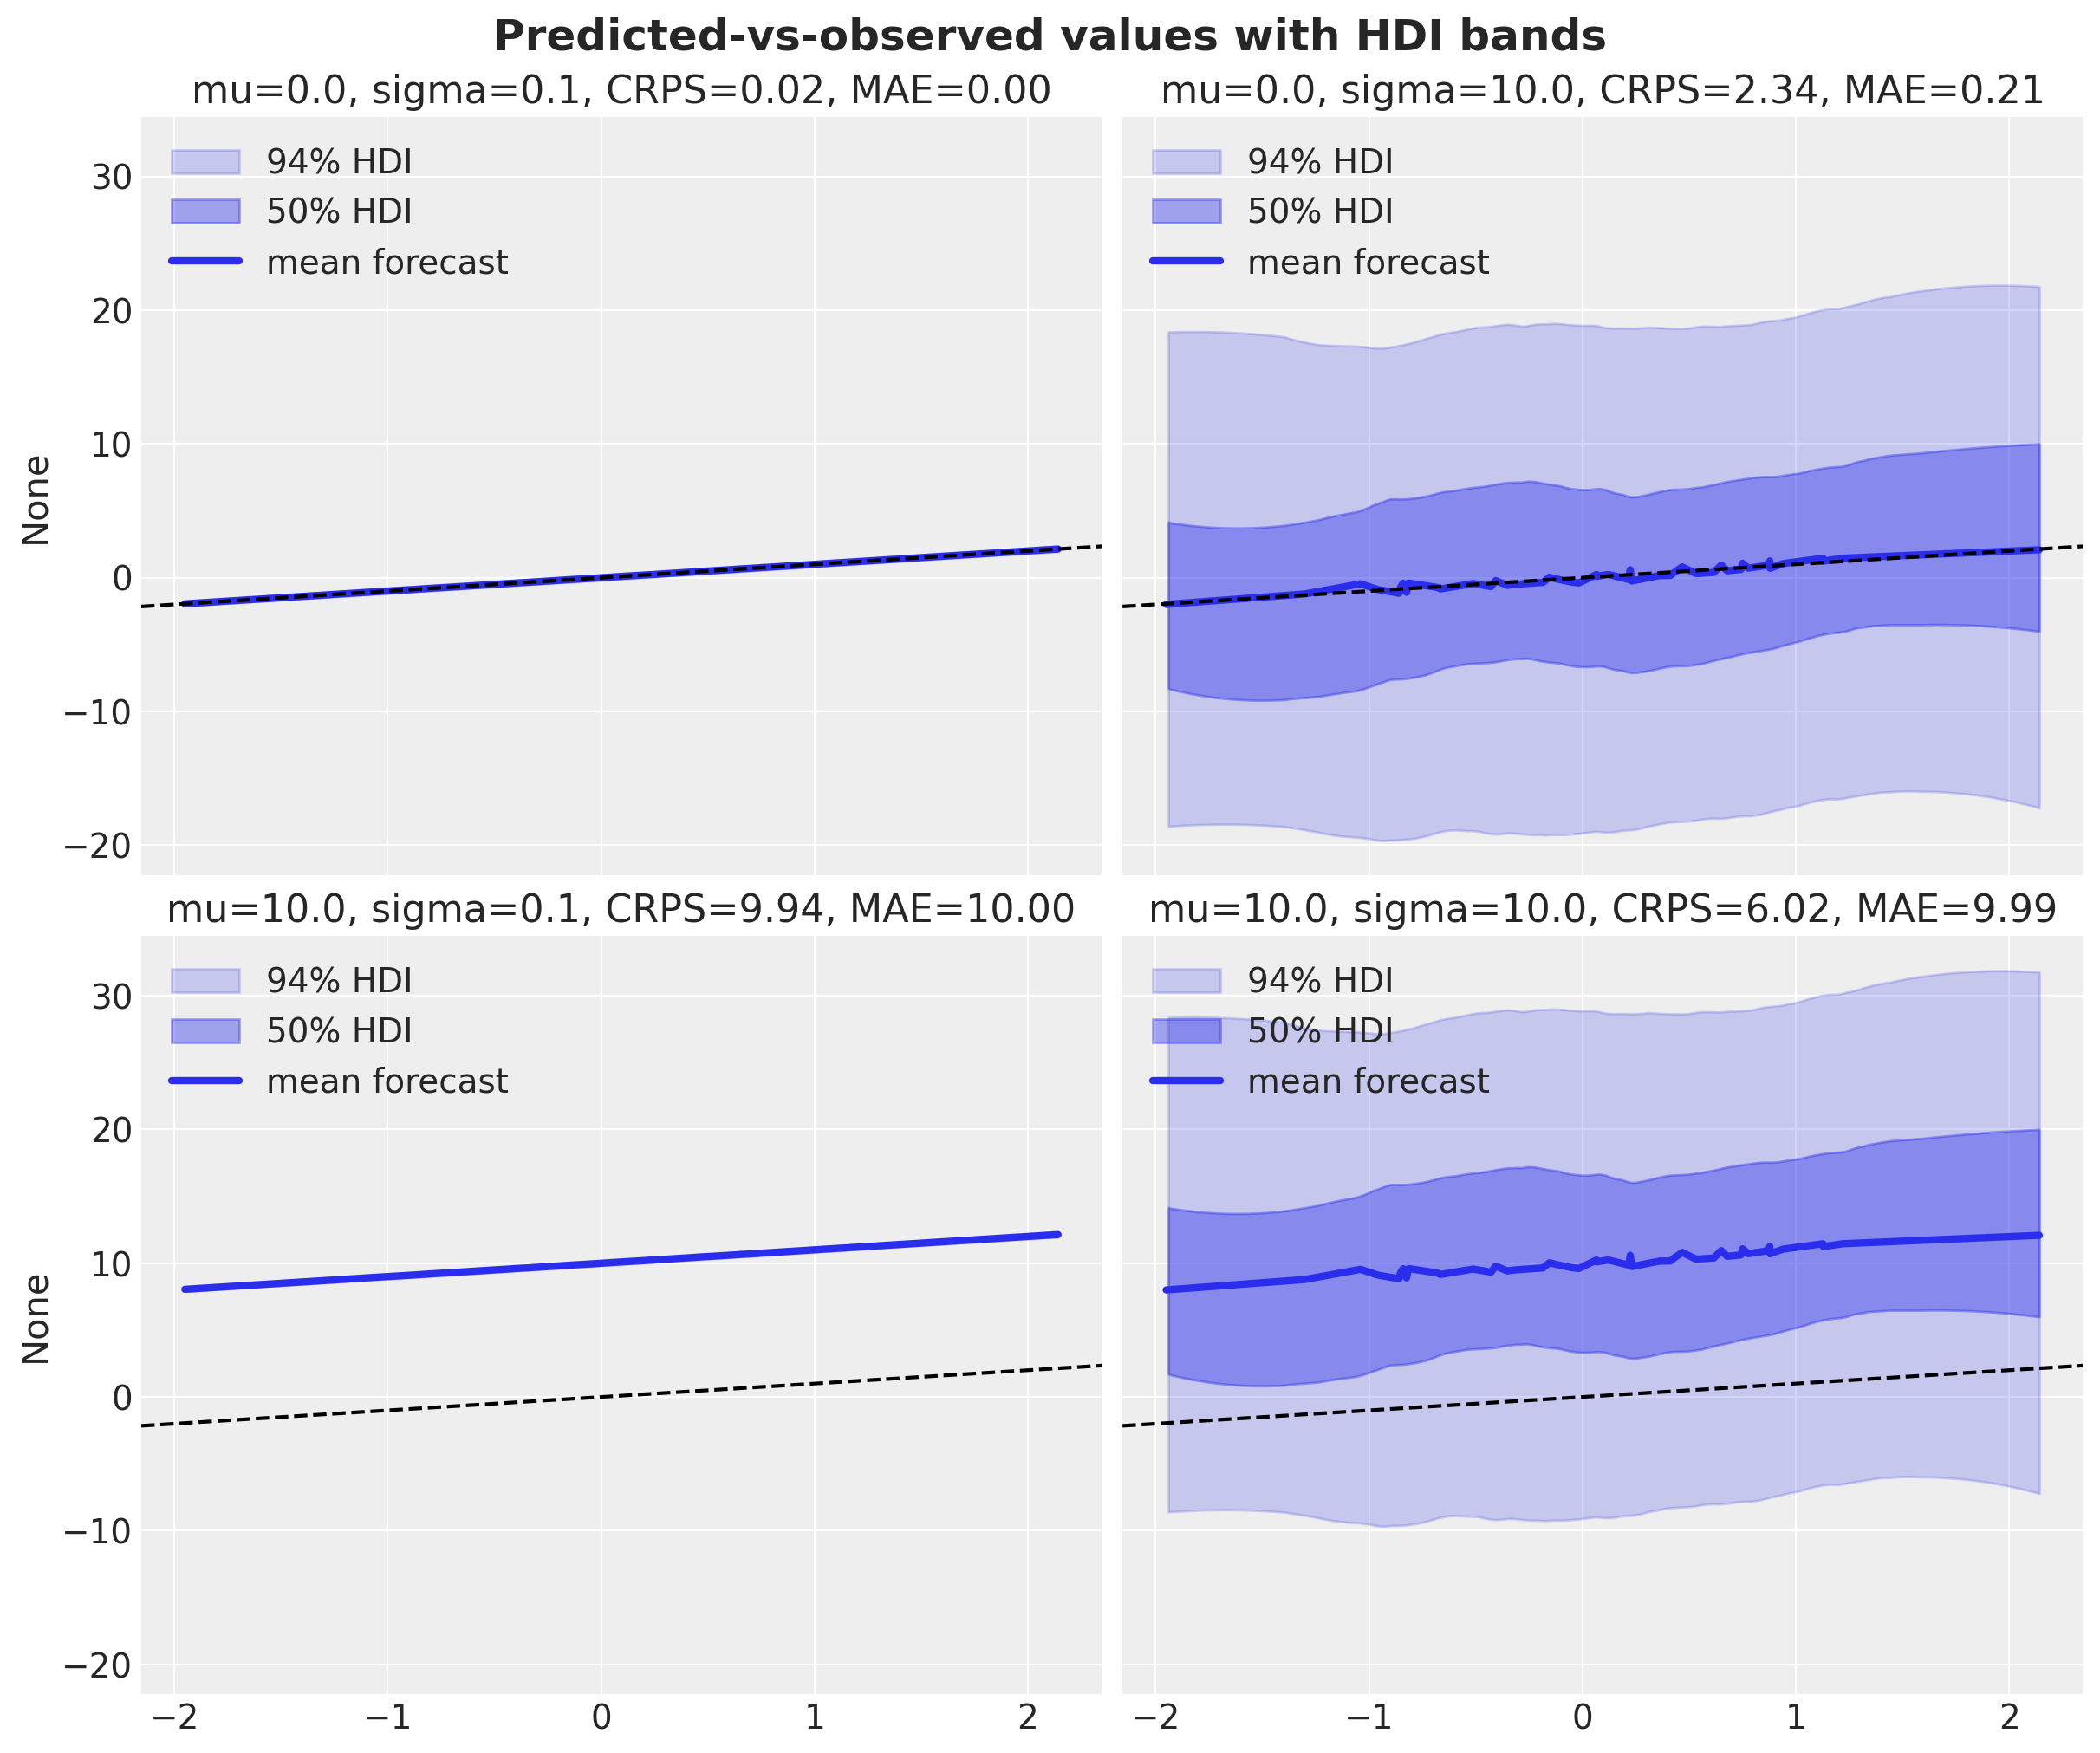

In [3]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
    layout="constrained",
)


def _plot_hdi(y_true, _y_pred, mu, sigma, ax):
    for i, hdi_prob in enumerate([0.94, 0.5]):
        az.plot_hdi(
            y_true,
            _y_pred,
            color="C0",
            hdi_prob=hdi_prob,
            fill_kwargs={
                "alpha": 0.2 + i * 0.2,
                "label": f"{hdi_prob:.0%} HDI",
            },
            ax=ax,
        )

    sns.lineplot(
        x=y_true,
        y=_y_pred.mean(dim=("chain", "draw")),
        color="C0",
        label="mean forecast",
        linewidth=3,
        ax=ax,
    )

    crps_value = crps(y_true, _y_pred.sel(chain=0))
    mae_value = mae(y_true, _y_pred.mean(dim=("chain", "draw")))
    ax.axline((0, 0), slope=1, color="black", linestyle="--")
    ax.legend(loc="upper left")
    ax.set_title(
        f"mu={mu:.1f}, sigma={sigma:.1f}, CRPS={crps_value:.2f}, MAE={mae_value:.2f}"
    )


combinations = [
    (mus[10], sigmas[0]),
    (mus[10], sigmas[-1]),
    (mus[-1], sigmas[0]),
    (mus[-1], sigmas[-1]),
]

for ax, (mu, sigma) in zip(axes.flatten(), combinations, strict=True):
    _plot_hdi(y_true, y_pred.sel(mu=mu, sigma=sigma), mu, sigma, ax)

fig.suptitle(
    "Predicted-vs-observed values with HDI bands", fontsize=18, fontweight="bold"
);

Next, we average predictions over $\sigma$ and draws to isolate the effect of the location shift $\mu$. As $|\mu|$ grows, the mean predictions shift away from the diagonal, visualizing pure bias.

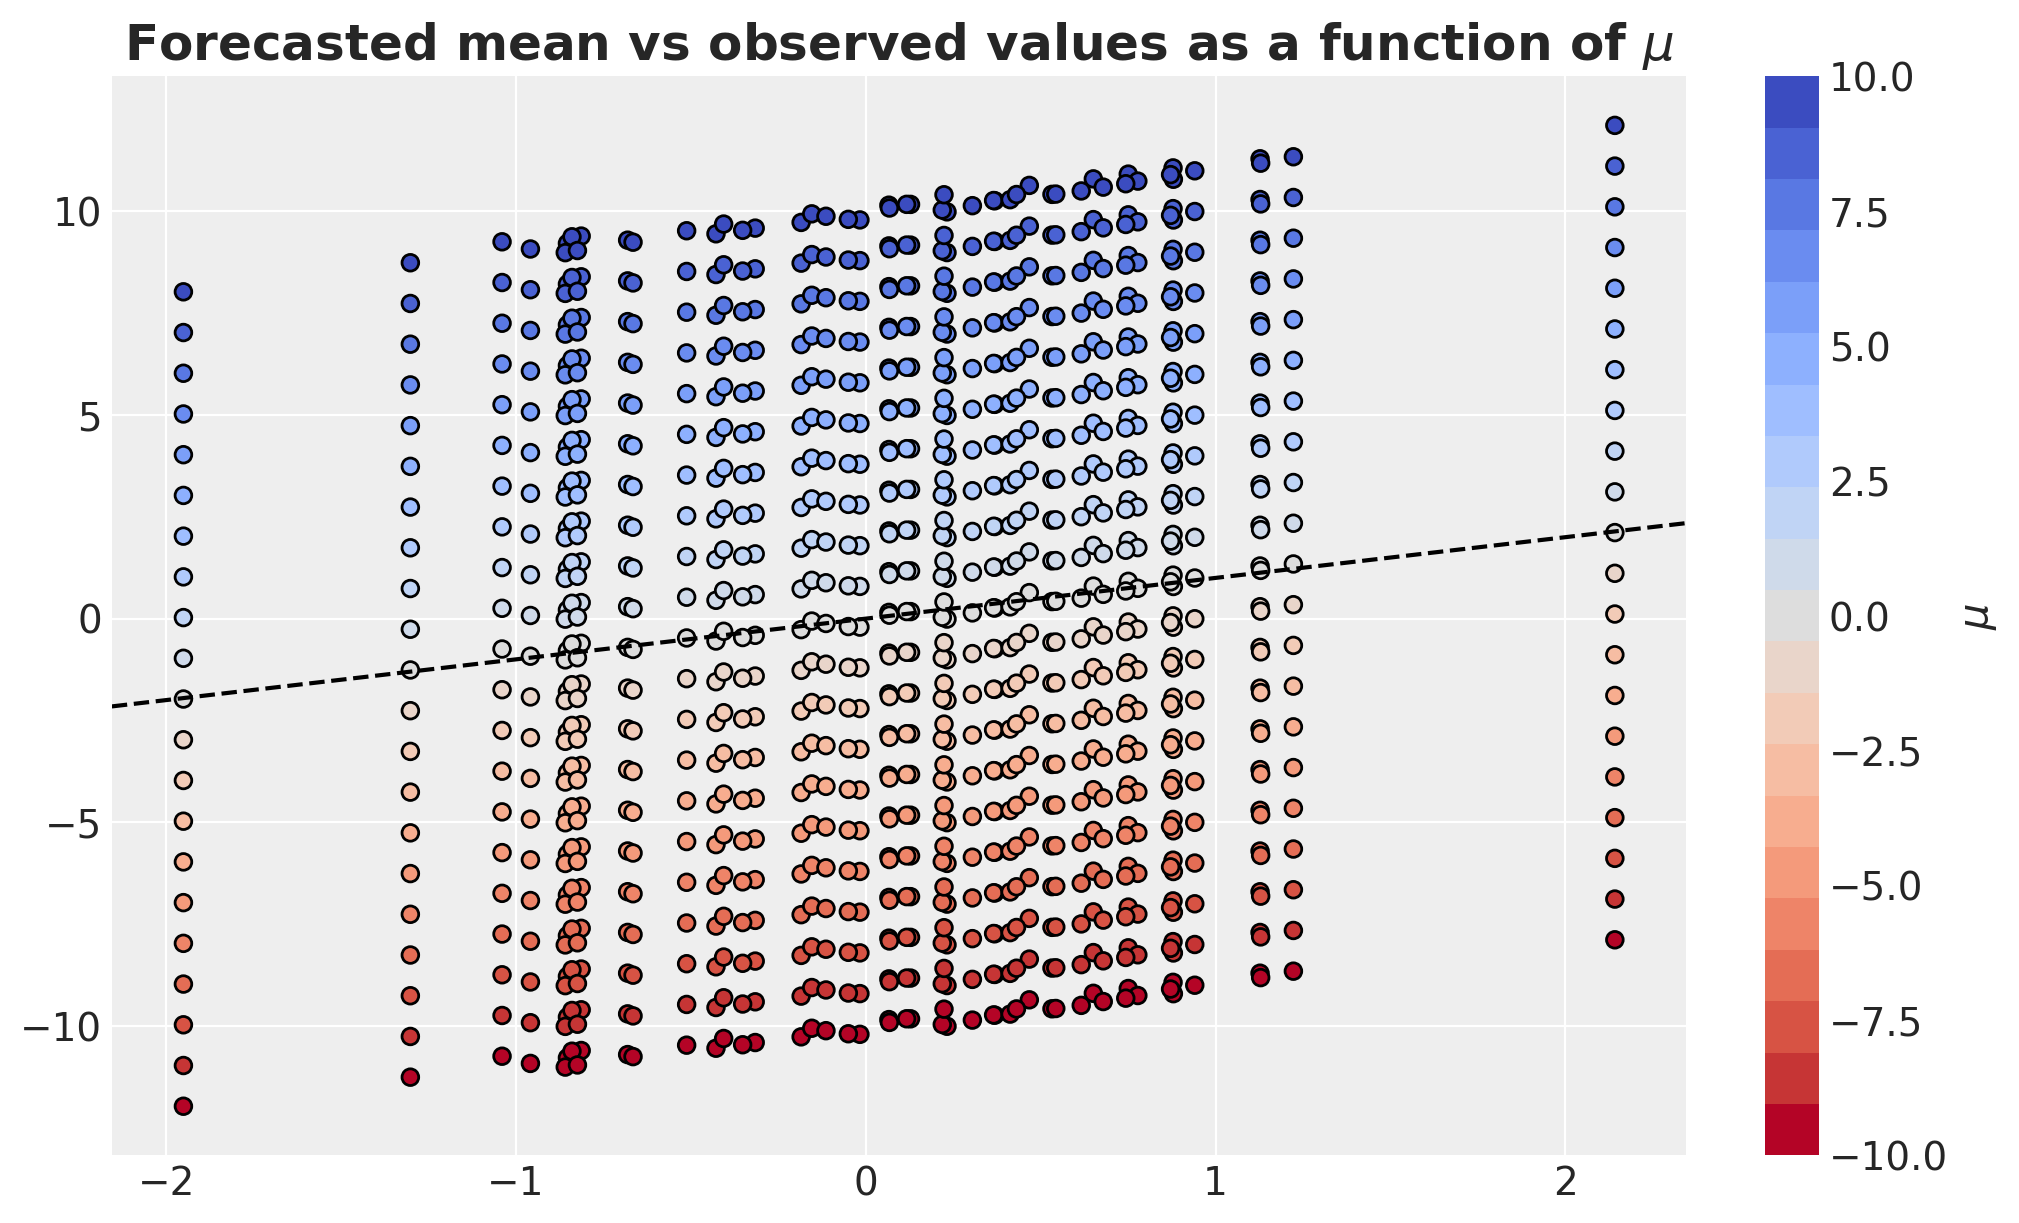

In [4]:
y_pred.sel(mu=0).mean(dim=("chain", "draw", "sigma"))

cmap = plt.get_cmap("coolwarm_r", k)

fig, ax = plt.subplots(figsize=(10, 6))

sc = None
for mu in mus:
    _y_pred_mean = y_pred.sel(mu=mu).mean(dim=("chain", "draw", "sigma"))
    sc = ax.scatter(
        y_true,
        _y_pred_mean,
        edgecolor="black",
        label=f"mu={mu:.2f}",
        c=[mu] * len(y_true),
        vmin=mus[0],
        vmax=mus[-1],
        cmap=cmap,
    )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", label=r"$\mu$")
ax.axline((0, 0), slope=1, color="black", linestyle="--")
ax.set_title(
    r"Forecasted mean vs observed values as a function of $\mu$",
    fontsize=18,
    fontweight="bold",
);

Similarly, we average over $\mu$ and draws to isolate the effect of the scale parameter $\sigma$. The mean predictions cluster near the diagonal regardless of $\sigma$, showing that collapsing the predictive distribution to its mean erases all information about the predicted spread.

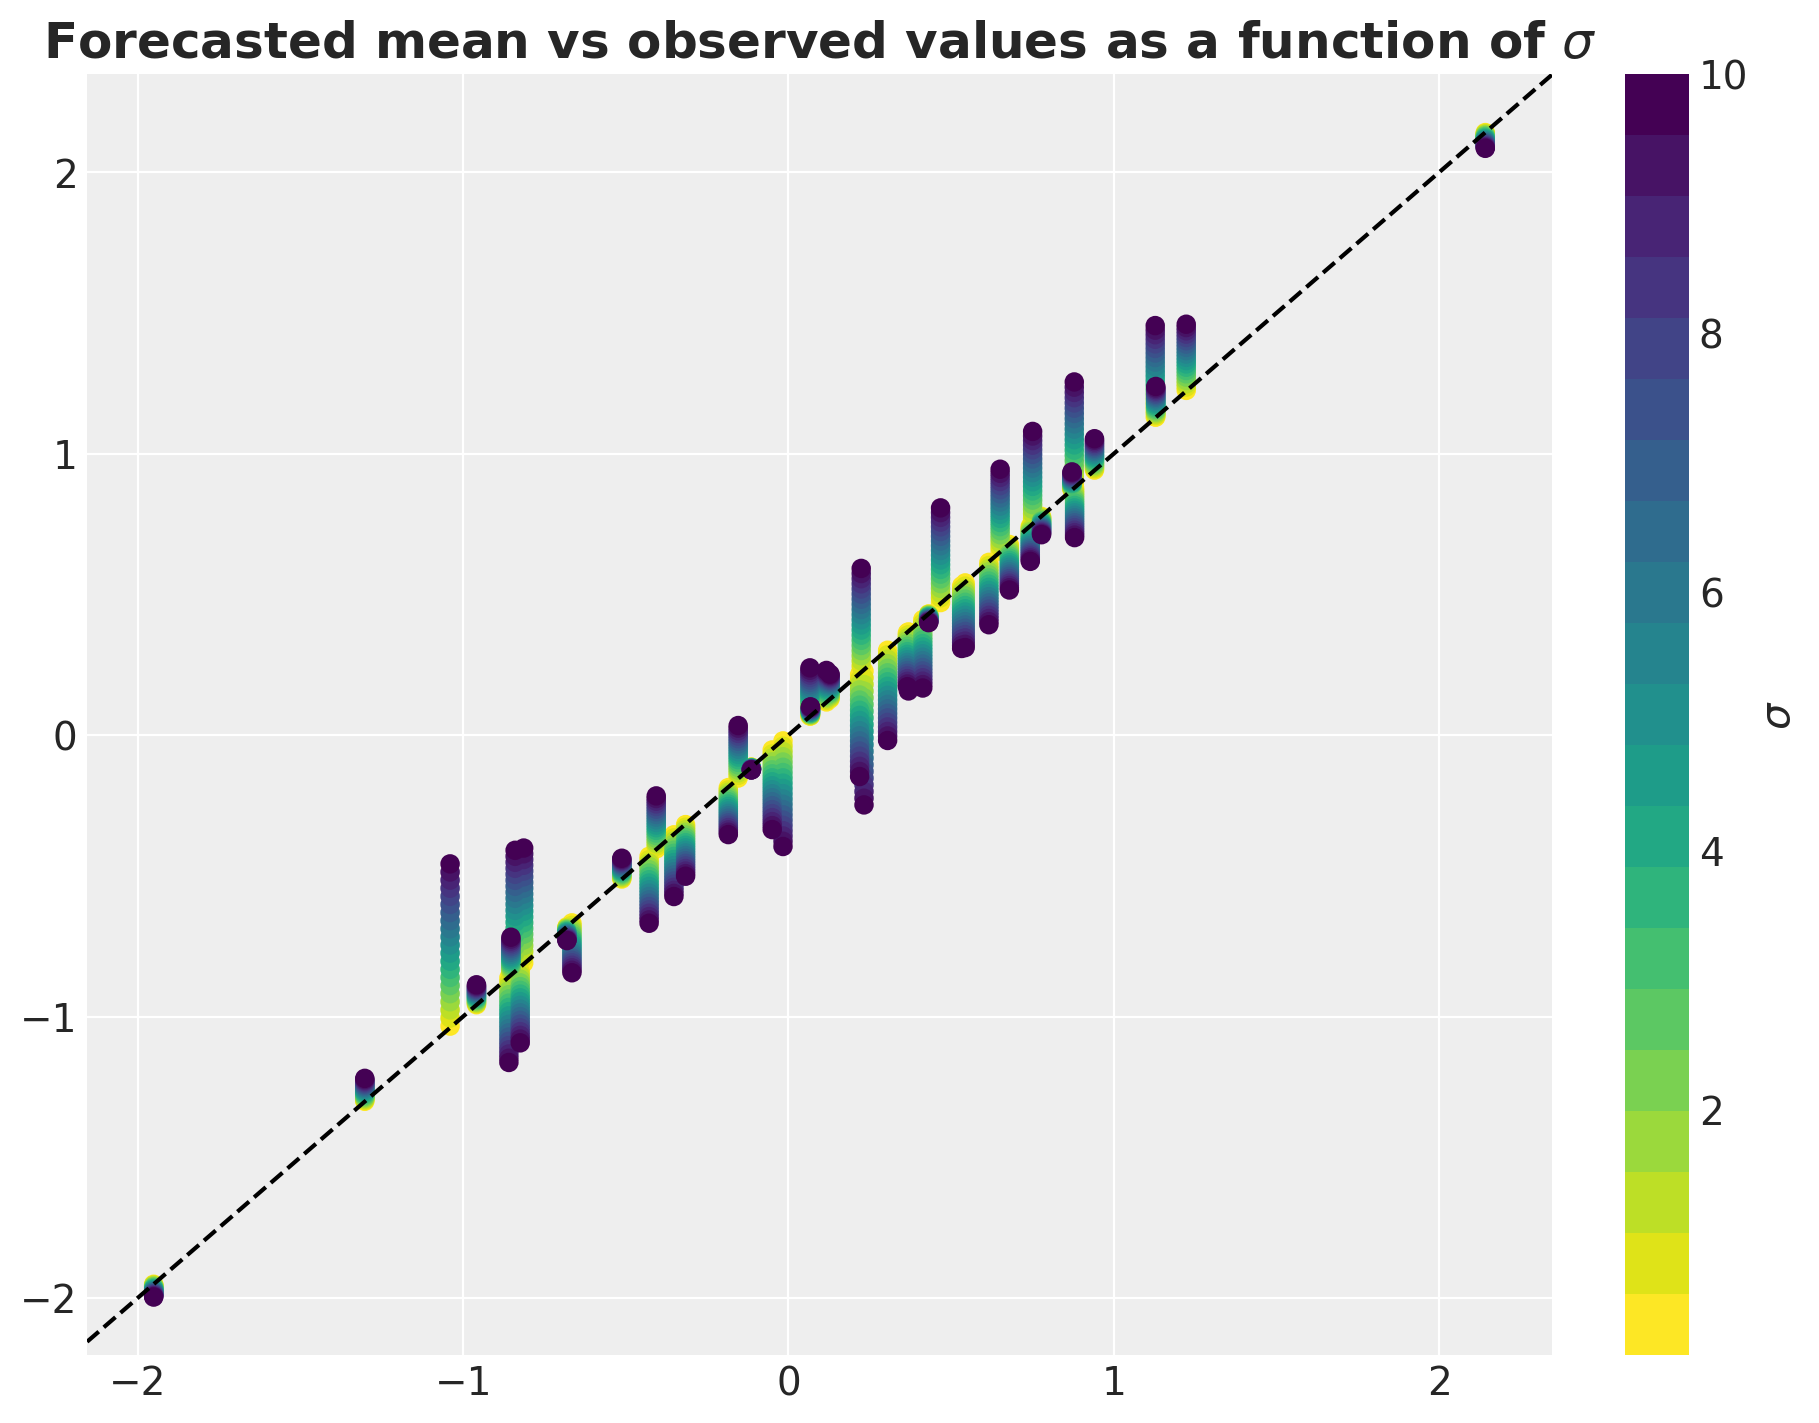

In [5]:
y_pred.sel(mu=0).mean(dim=("chain", "draw", "sigma"))

cmap = plt.get_cmap("viridis_r", k)

fig, ax = plt.subplots(figsize=(9, 7))

sc = None
for sigma in sigmas:
    _y_pred_mean = y_pred.sel(sigma=sigma).mean(dim=("chain", "draw", "mu"))
    sc = ax.scatter(
        y_true,
        _y_pred_mean,
        label=f"sigma={sigma:.2f}",
        c=[sigma] * len(y_true),
        vmin=sigmas[0],
        vmax=sigmas[-1],
        cmap=cmap,
    )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", label=r"$\sigma$")
ax.axline((0, 0), slope=1, color="black", linestyle="--")
ax.set_title(
    r"Forecasted mean vs observed values as a function of $\sigma$",
    fontsize=18,
    fontweight="bold",
);

## CRPS vs MAE Comparison

We now compute the CRPS and MAE for every $(\mu, \sigma)$ pair and display them as side-by-side heatmaps. This is the central result of the notebook: it reveals how each metric responds to changes in bias and spread.

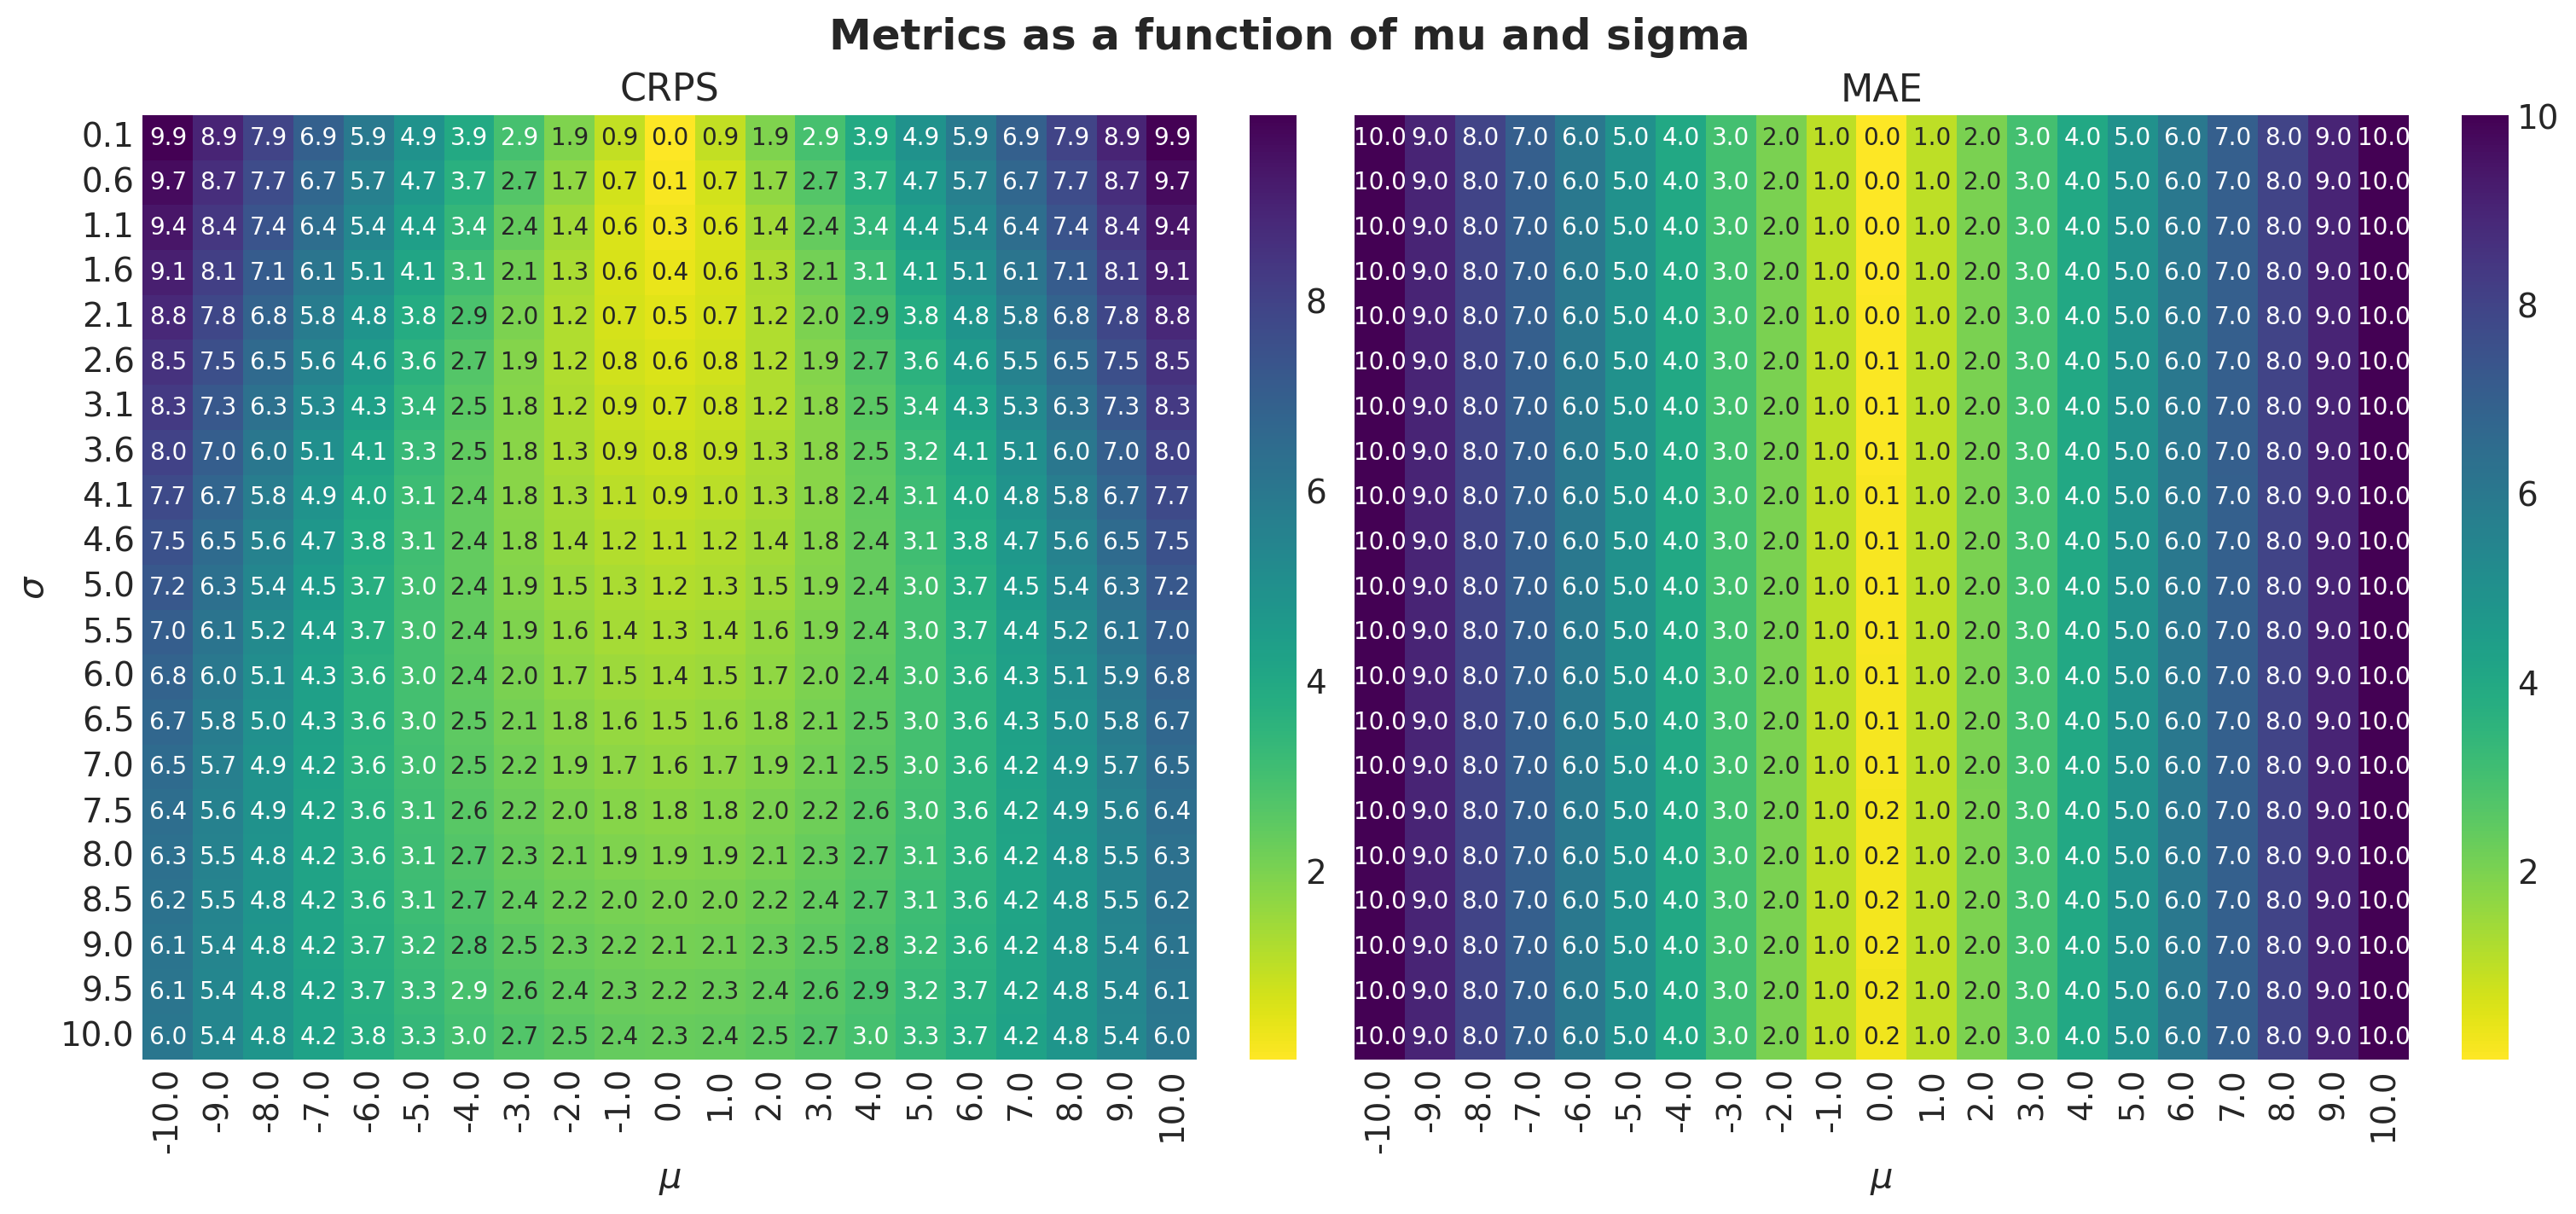

In [6]:
crps_values = np.empty((len(mus), len(sigmas)))
maes_values = np.empty((len(mus), len(sigmas)))

for i, sigma in enumerate(sigmas):
    for j, mu in enumerate(mus):
        _y_pred = y_pred.sel(chain=0, sigma=sigma, mu=mu)
        crps_values[i, j] = crps(y_true, _y_pred)
        maes_values[i, j] = mae(y_true, _y_pred.mean(dim=("draw")))

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 7),
    sharex=True,
    sharey=True,
    layout="constrained",
)

sns.heatmap(
    crps_values,
    cmap="viridis_r",
    annot=True,
    fmt=".1f",
    xticklabels=[f"{mu:.1f}" for mu in mus],
    yticklabels=[f"{sigma:.1f}" for sigma in sigmas],
    ax=ax[0],
)
ax[0].set(title="CRPS", xlabel=r"$\mu$", ylabel=r"$\sigma$")

sns.heatmap(
    maes_values,
    cmap="viridis_r",
    annot=True,
    fmt=".1f",
    xticklabels=[f"{mu:.1f}" for mu in mus],
    yticklabels=[f"{sigma:.1f}" for sigma in sigmas],
    ax=ax[1],
)
ax[1].set(title="MAE", xlabel=r"$\mu$")

fig.suptitle("Metrics as a function of mu and sigma", fontsize=18, fontweight="bold");

The heatmaps confirm the key observation: the MAE varies only along the $\mu$ axis (bias) and is almost constant along $\sigma$ (since we are averaging over draws), because collapsing to the mean discards spread information. The CRPS, in contrast, varies along both axes: it penalizes bias *and* spread, with a clear optimum near $(\mu = 0,\; \sigma \approx 1)$.

## Conclusion

This simple experiment highlights why the CRPS is a strictly more informative metric than the MAE for evaluating probabilistic forecasts. While the MAE only captures location error (bias), the CRPS simultaneously rewards **calibration** and **sharpness**, penalizing predictions whose spread is either too wide or too narrow for the observed data. 